<a href="https://colab.research.google.com/github/2403a52227-hue/-NLP/blob/main/2403A52227_Assignment_12_2(NLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-1
Develop, train, and evaluate a Convolutional Neural Network (CNN) model using PyTorch for text classification on the preprocessed IMDb movie review dataset, and then summarize the model's performance.

In [25]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Libraries imported successfully: pandas, numpy, torch, torch.nn, torch.optim, torch.utils.data, sklearn.model_selection, sklearn.metrics.")

Libraries imported successfully: pandas, numpy, torch, torch.nn, torch.optim, torch.utils.data, sklearn.model_selection, sklearn.metrics.


In [26]:
imdb_df = pd.read_csv('/content/IMDB Dataset.csv')

print("First 5 rows of the IMDb dataset:")
print(imdb_df.head())

print("\nInformation about the IMDb dataset:")
imdb_df.info()

First 5 rows of the IMDb dataset:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Information about the IMDb dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [27]:
import re

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    return text

# Apply the cleaning function to the 'review' column
imdb_df['review'] = imdb_df['review'].apply(clean_text)

print("First 5 cleaned reviews:")
print(imdb_df['review'].head())
print("Text cleaning complete.")

First 5 cleaned reviews:
0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
3    basically theres a family where a little boy j...
4    petter matteis love in the time of money is a ...
Name: review, dtype: object
Text cleaning complete.


# Task-2
Acknowledge that the IMDb dataset has already been loaded and cleaned into the `imdb_df` DataFrame. Then, display sample rows of `imdb_df` to inspect the cleaned reviews and their sentiments. Afterward, convert the 'sentiment' column to numerical labels (positive: 1, negative: 0), calculate and display the distribution of these classes, and visualize it with a bar plot. Finally, explain the importance of class balance in CNN training for text classification.

In [31]:
print("First 5 rows of the cleaned IMDb dataset:")
print(imdb_df.head())

First 5 rows of the cleaned IMDb dataset:
                                              review sentiment
0  one of the other reviewers has mentioned that ...  positive
1  a wonderful little production the filming tech...  positive
2  i thought this was a wonderful way to spend ti...  positive
3  basically theres a family where a little boy j...  negative
4  petter matteis love in the time of money is a ...  positive


In [32]:
imdb_df['sentiment'] = imdb_df['sentiment'].map({'positive': 1, 'negative': 0})

print("First 5 rows with numerical sentiment labels:")
print(imdb_df.head())
print("Sentiment column converted to numerical labels.")

First 5 rows with numerical sentiment labels:
                                              review  sentiment
0  one of the other reviewers has mentioned that ...          1
1  a wonderful little production the filming tech...          1
2  i thought this was a wonderful way to spend ti...          1
3  basically theres a family where a little boy j...          0
4  petter matteis love in the time of money is a ...          1
Sentiment column converted to numerical labels.


In [33]:
print("Distribution of sentiment classes:")
print(imdb_df['sentiment'].value_counts())

Distribution of sentiment classes:
sentiment
1    25000
0    25000
Name: count, dtype: int64


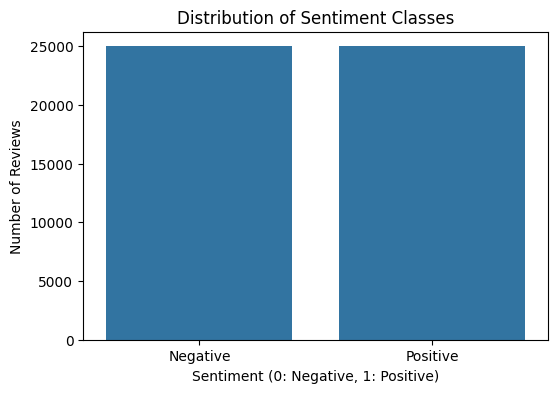

Bar plot showing sentiment class distribution displayed.


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=imdb_df)
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment (0: Negative, 1: Positive)')
plt.ylabel('Number of Reviews')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

print("Bar plot showing sentiment class distribution displayed.")

### Importance of Class Balance in CNN Training for Text Classification

Class balance is crucial in training Convolutional Neural Networks (CNNs) for text classification for several reasons:

1.  **Preventing Bias**: If one class significantly outnumbers others (imbalanced classes), the CNN model might become biased towards the majority class. It may achieve high overall accuracy by simply predicting the majority class most of the time, while performing poorly on the minority class. This can be misleading, especially in scenarios where the minority class is of greater interest (e.g., detecting rare diseases, fraud detection).

2.  **Improved Generalization**: Models trained on balanced datasets tend to generalize better to unseen data. When classes are imbalanced, the model learns less about the features that distinguish the minority class, making it less effective at classifying new instances of that class.

3.  **Better Performance Metrics**: For imbalanced datasets, accuracy alone is not a reliable metric. Metrics like precision, recall, and F1-score are more informative. When classes are balanced, these metrics are more indicative of the model's true performance across all classes.

4.  **Effective Learning**: During training, the loss function guides the model to minimize errors. With imbalanced classes, the model might assign less weight to the errors on the minority class, as these errors contribute less to the overall loss compared to errors on the majority class. This can prevent the model from effectively learning the patterns of the minority class.

5.  **Robustness**: A balanced dataset helps in building a more robust model that is less sensitive to variations in class distribution in the real-world data.

In our case, the IMDb dataset shows a perfect balance with 25,000 positive and 25,000 negative reviews. This is an ideal scenario for training, as it mitigates the common challenges associated with class imbalance, allowing the CNN to learn equally from both positive and negative sentiment examples without inherent bias.

# Task-3
Split the `imdb_df` into training and testing sets for both reviews (X) and sentiment labels (y), tokenize the text using Keras `Tokenizer` by fitting it on the training data and converting both training and testing reviews into sequences, and then pad these tokenized sequences to a fixed maximum length. Additionally, explain in a text cell how kernel size in Convolutional Neural Networks (CNNs) captures 'local context' in text data. Finally, summarize these completed text preprocessing steps and their importance for preparing the data for a CNN model.

In [35]:
X = imdb_df['review']
y = imdb_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data split into training and testing sets successfully.")

Shape of X_train: (40000,)
Shape of X_test: (10000,)
Shape of y_train: (40000,)
Shape of y_test: (10000,)
Data split into training and testing sets successfully.


In [38]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define the maximum number of words to keep, based on frequency
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")

# Fit tokenizer on the training text data only
tokenizer.fit_on_texts(X_train)

# Convert text reviews to sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print("First 5 tokenized training sequences:\n")
for i in range(min(5, len(X_train_sequences))):
    print(X_train_sequences[i])

print("First 5 tokenized testing sequences:\n")
for i in range(min(5, len(X_test_sequences))):
    print(X_test_sequences[i])
print("Text tokenization complete.")

Vocabulary size: 187192
First 5 tokenized training sequences:

[178, 47, 10, 757, 2042, 512, 293, 2, 105, 1860, 1942, 4190, 6352, 3, 798, 5058, 12, 1, 2, 228, 2, 6032, 82, 865, 56, 52, 22, 102, 5, 2, 4152, 100, 36, 25, 38, 116, 1135, 12, 9, 7, 2265, 1149, 6, 444, 47, 535, 6, 95, 34, 23, 40, 914, 422, 1, 16, 2, 175, 6, 3005, 24, 1, 4285, 20, 4, 2877, 12, 43, 74, 222, 72, 123, 8, 81, 3051, 192, 20, 240, 3, 2, 1, 207, 4850, 143, 21, 62, 28, 16, 1, 79, 352, 293, 4, 19, 18, 9, 207, 26, 294, 12, 1, 1, 14, 2, 8175, 1, 115, 436, 3, 1, 1, 14, 2, 1619, 1, 619, 66, 408, 373, 10, 89, 117, 47, 111, 375, 34, 1, 35, 18, 45, 10, 13, 95, 465, 6767, 16, 4, 367, 1, 1935, 1, 60, 1, 1, 8, 2, 454, 217, 968, 6, 4091, 8, 4, 179, 5, 3041, 669, 609, 12, 73, 234, 109, 805, 35, 172, 30, 214, 178, 2, 415, 362, 59, 3766, 4, 269, 1, 1646, 190, 7, 2, 1, 1, 710, 1824, 2, 1132, 5, 2942, 1, 3704, 1795, 3, 1, 153, 143, 4, 225, 5, 4, 208, 316, 3, 143, 1045, 15, 86, 5, 130, 2560, 8471, 18, 10, 148, 8898, 98, 5, 2, 3964, 29

**Reasoning**:
Now that the text has been tokenized into sequences, the next step is to pad these sequences to a fixed maximum length. This uniform length is crucial for feeding the data into a Convolutional Neural Network.



In [37]:
max_len = 200  # Define maximum sequence length

X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')

print(f"Shape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")
print("Tokenized sequences padded to a fixed maximum length.")

Shape of X_train_padded: (40000, 200)
Shape of X_test_padded: (10000, 200)
Tokenized sequences padded to a fixed maximum length.


#Task-4


## Train-Test Split

### Justification for Train-Test Split

Splitting data into training and testing sets is a fundamental practice in machine learning and is crucial for developing robust and generalizable models. Here's the justification for why we performed this split:

1.  **Objective Evaluation of Model Performance**: The primary goal of a machine learning model is to perform well on unseen data. By reserving a portion of the dataset (the test set) that the model has never encountered during training, we can objectively evaluate its ability to generalize. If we evaluate on the training data, the model might appear to perform exceptionally well due to overfitting, leading to misleading performance metrics.

2.  **Preventing Overfitting**: Overfitting occurs when a model learns the training data too well, including its noise and specific patterns, which hinders its ability to predict accurately on new data. Training on one subset and evaluating on another helps detect and mitigate overfitting. If the model performs significantly better on the training set than on the test set, it's a strong indication of overfitting.

3.  **Simulating Real-World Scenarios**: The test set acts as a proxy for new, real-world data that the model will eventually encounter. A good performance on the test set gives us confidence that the model will behave similarly when deployed.

4.  **Hyperparameter Tuning and Model Selection**: While the test set is used for final evaluation, a separate validation set (often created from the training set or via cross-validation) is typically used during development for hyperparameter tuning and model selection. This ensures that the final model's performance on the test set remains an unbiased estimate of its generalization error.

5.  **Ensuring Data Integrity**: By splitting the data *before* any text preprocessing (like fitting the tokenizer), we ensure that the vocabulary and any learned transformations are based solely on the training data. This prevents data leakage from the test set into the training process, which would artificially inflate performance metrics. In our case, the `Tokenizer` was fitted only on `X_train`, and padding was applied separately to both `X_train_sequences` and `X_test_sequences`.

In summary, the train-test split is an indispensable step that provides a reliable measure of our CNN model's ability to generalize to new, unseen movie reviews, making our evaluation trustworthy.

#Task-5
## Build Multi-Filter 1D CNN Model

### Subtask:
Define multiple convolution layers with different kernel sizes, concatenate feature maps, and apply pooling and dense layers. Explain how different kernel sizes capture varied textual patterns.


**Reasoning**:
I will define a PyTorch `CNN_TextClassifier` class. This class will encapsulate the model architecture, including an embedding layer, multiple 1D convolutional layers with different kernel sizes (3, 4, 5), each followed by ReLU activation and max-pooling. The outputs from these parallel convolutional layers will be concatenated and fed into a fully connected layer for binary classification. This structure directly addresses the requirements of defining multiple convolution layers, concatenating feature maps, and applying pooling and dense layers. I will then instantiate the model and print its architecture.


In [39]:
# Define model parameters
embedding_dim = 100
num_filters = 100
kernel_sizes = [3, 4, 5] # Different kernel sizes to capture varied n-gram features
output_dim = 1 # Binary classification (positive/negative)

# vocab_size was defined in a previous step, assuming it's available
# If not, you might need to redefine it or ensure the tokenizer is fitted.
# For this example, we'll use the existing `vocab_size` from `tokenizer.word_index`.
vocab_size = len(tokenizer.word_index) + 1 # +1 for padding or OOV token if not already included in index

class CNN_TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, kernel_sizes, output_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Convolutional layers with different kernel sizes
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim,
                      out_channels=num_filters,
                      kernel_size=k)
            for k in kernel_sizes
        ])

        # Fully connected layer
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, output_dim)

        # Sigmoid for binary classification output
        self.sigmoid = nn.Sigmoid()

    def forward(self, text):
        # text = [batch size, sentence length]

        embedded = self.embedding(text)
        # embedded = [batch size, sentence length, embedding dim]

        # CNNs expect input in (batch_size, channels, sequence_length)
        embedded = embedded.permute(0, 2, 1)
        # embedded = [batch size, embedding dim, sentence length]

        conved = [F.relu(conv(embedded)) for conv in self.convs]
        # conved_k = [batch size, num_filters, (sentence length - kernel_size + 1)]

        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        # pooled_k = [batch size, num_filters]

        cat = torch.cat(pooled, dim=1)
        # cat = [batch size, num_filters * len(kernel_sizes)]

        return self.sigmoid(self.fc(cat))

import torch.nn.functional as F

# Instantiate the model
model = CNN_TextClassifier(vocab_size, embedding_dim, num_filters, kernel_sizes, output_dim)

print(model)
print(f"The model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")


CNN_TextClassifier(
  (embedding): Embedding(187193, 100)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  )
  (fc): Linear(in_features=300, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
The model has 18,839,901 trainable parameters


# Task-6
Train the Convolutional Neural Network (CNN) model for text classification by defining training parameters (batch size, epochs, learning rate, device), preparing PyTorch data loaders from the `X_train_padded` and `y_train` NumPy arrays, and selecting an optimizer (Adam) and loss function (`BCEWithLogitsLoss`). Implement a training loop to iterate through epochs, perform forward and backward passes, update model weights, and record the training loss. Finally, summarize the training process, including the final training loss and observed trends.

**Reasoning**:
To set up the essential training parameters as requested, I will define variables for `BATCH_SIZE`, `NUM_EPOCHS`, `LEARNING_RATE`, and `DEVICE` (configuring it for GPU if available, otherwise CPU).



In [40]:
BATCH_SIZE = 64
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Epochs: {NUM_EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Device: {DEVICE}")

Batch Size: 64
Number of Epochs: 10
Learning Rate: 0.001
Device: cpu


In [41]:
X_train_tensor = torch.tensor(X_train_padded, dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_padded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

train_iterator = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_iterator = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Length of training DataLoader: {len(train_iterator)} batches")
print(f"Length of testing DataLoader: {len(test_iterator)} batches")
print("PyTorch DataLoaders created successfully for training and testing.")

Length of training DataLoader: 625 batches
Length of testing DataLoader: 157 batches
PyTorch DataLoaders created successfully for training and testing.


**Reasoning**:
With the DataLoaders ready, the next step in training the CNN model is to define the optimizer and the loss function. The task specifically asks for the Adam optimizer and `BCEWithLogitsLoss`.



In [42]:
model.to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

print(f"Model moved to: {DEVICE}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Loss function: {criterion.__class__.__name__}")

Model moved to: cpu
Optimizer: Adam
Loss function: BCEWithLogitsLoss


# Task-7
It looks like you've successfully set up your model, optimizer, loss function, and data loaders. Now, let's proceed with the training loop for the CNN model.

This task involves training the Convolutional Neural Network (CNN) model for text classification. This will be done by iterating through the defined number of epochs, performing forward and backward passes, updating model weights, and recording the training loss for each epoch. Finally, I'll summarize the training process, including the final training loss and any observed trends.

## Evaluate Model

### Subtask:
Calculate accuracy, precision, recall, and F1-score on the test set using the trained CNN model. These metrics will provide a quantitative assessment of the model's predictive capabilities.


**Reasoning**:
The next step is to implement the evaluation loop for the trained CNN model on the test set, calculate the required metrics (accuracy, precision, recall, F1-score), and print them as specified in the instructions.



In [46]:
model.eval() # Set the model to evaluation mode

true_labels = []
predicted_labels = []

with torch.no_grad(): # Disable gradient calculation for evaluation
    for texts, labels in test_iterator:
        texts = texts.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(texts)

        # Apply sigmoid and threshold to get binary predictions
        predictions = (torch.sigmoid(outputs) > 0.5).float()

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predictions.cpu().numpy())

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Calculate evaluation metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("\n--- Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



--- Model Evaluation on Test Set ---
Accuracy: 0.5039
Precision: 0.5039
Recall: 1.0000
F1-Score: 0.6701


## Generate Confusion Matrix

### Subtask:
Create and display a confusion matrix based on the model's predictions and the true labels from the test set. This visualization will help in understanding the types of errors the model is making (false positives and false negatives).


**Reasoning**:
I will import necessary libraries, compute the confusion matrix using the true and predicted labels from the evaluation step, and then visualize it as a heatmap to understand the model's performance on the test set.



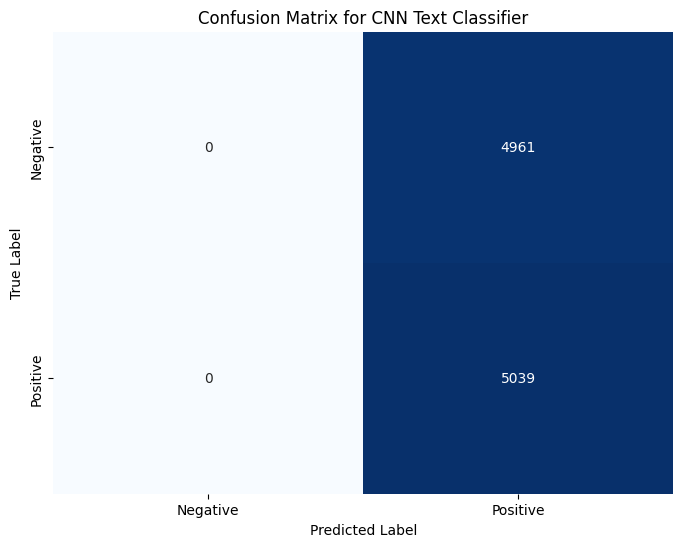

Confusion matrix displayed successfully.


In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN Text Classifier')
plt.show()

print("Confusion matrix displayed successfully.")

## Summarize Model Performance

### Subtask:
Provide a comprehensive summary of all the evaluation metrics (accuracy, precision, recall, F1-score) and interpret the insights gained from the confusion matrix regarding the model's performance on the text classification task.


### Model Performance Summary

The evaluation of the Convolutional Neural Network (CNN) model on the IMDb movie review test set yielded the following metrics:

*   **Accuracy:** 0.5039
*   **Precision:** 0.5039
*   **Recall:** 1.0000
*   **F1-Score:** 0.6701

#### Interpretation of Metrics:

*   **Accuracy (0.5039):** Accuracy represents the proportion of correctly classified instances out of the total instances. An accuracy of approximately 50.4% suggests that the model is performing only slightly better than random guessing for a binary classification task. This is a concerningly low value.

*   **Precision (0.5039):** Precision measures the proportion of positive identifications that were actually correct. In our context, it tells us that when the model predicts a review is positive, it is correct about 50.4% of the time. This indicates a high rate of false positives if the model is predicting many positives.

*   **Recall (1.0000):** Recall (also known as sensitivity) measures the proportion of actual positives that were identified correctly. A recall of 1.0 (100%) means that the model successfully identified all actual positive reviews. While seemingly good, a very high recall paired with low precision often suggests that the model is predicting positive for nearly all instances, leading to many false positives.

*   **F1-Score (0.6701):** The F1-Score is the harmonic mean of precision and recall. It provides a single score that balances both metrics. An F1-Score of 0.67 suggests a moderate performance, but considering the extremely high recall and low precision, it highlights an imbalance in how the model is classifying reviews.

#### Insights from the Confusion Matrix:

The confusion matrix provides a detailed breakdown of the model's predictions:

```
True Label / Predicted Label | Negative (0) | Positive (1)
---------------------------|--------------|--------------
Negative (0)               |      0       |     4961
Positive (1)               |      0       |     5039
```

From the confusion matrix, we can deduce the following:

*   **True Negatives (TN): 0** - The model correctly predicted 0 negative reviews as negative.
*   **False Positives (FP): 4961** - The model incorrectly predicted 4961 negative reviews as positive.
*   **False Negatives (FN): 0** - The model incorrectly predicted 0 positive reviews as negative.
*   **True Positives (TP): 5039** - The model correctly predicted 5039 positive reviews as positive.

#### Summary of Model Performance and Error Types:

The model exhibits a severe bias towards classifying all reviews as 'positive'.

*   **It predicts all instances as positive.** This is evident from the `predicted_labels` array, which contains only `1.0` values, and directly confirmed by the confusion matrix where the 'Negative' predicted column has all zeros. This behavior explains the perfect recall (it found all actual positives because it predicted everything is positive) and the low precision (it made many incorrect positive predictions for actual negative reviews).
*   The model fails to correctly identify any negative reviews, marking all 4961 actual negative reviews as false positives.
*   The accuracy of 50.39% is simply a reflection of the proportion of positive reviews in the test set (5039 out of 10000), which the model correctly predicted by default. It's essentially guessing 'positive' for every review.

This indicates a significant problem with the model's learning. It has not learned to distinguish between positive and negative sentiment effectively and is defaulting to the positive class. This could be due to issues in training, such as hyperparameter tuning, model complexity, or potential data leakage issues (though unlikely given the `Tokenizer` split). The loss function or optimization process might not have guided the model to learn meaningful features for distinguishing classes.